# Klasyfikacja obiektów astronomicznych — Stellar Classification Dataset (SDSS17)

**Przedmiot:** Sztuczne sieci neuronowe i algorytmy uczenia głębokiego

Notebook obejmuje import bibliotek, wczytanie danych, eksploracyjną analizę (EDA) oraz przygotowanie zbioru do dalszego trenowania modeli głębokiego uczenia.

> **Uwaga (Google Colab):** umieść plik `star_classification.csv` w folderze `data/` w katalogu roboczym lub zmień ścieżkę w sekcji 2.

# Sekcja 1 – Import bibliotek

W tej sekcji importujemy wszystkie niezbędne biblioteki do analizy danych, wizualizacji oraz późniejszego trenowania sieci neuronowych. Ustawiamy również stały seed, aby wyniki były powtarzalne.

In [3]:
# --- Import bibliotek ---
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

import tensorflow as tf
from tensorflow import keras

# --- Ustawienia powtarzalności ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# --- Ustawienia wizualizacji ---
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")
print(f"Seed ustawiony na: {RANDOM_STATE}")

NumPy: 2.4.6
Pandas: 3.0.3
TensorFlow: 2.21.0
Keras: 3.14.1
Seed ustawiony na: 42


### Podsumowanie sekcji 1

Zaimportowano biblioteki do manipulacji danymi (`pandas`, `numpy`), wizualizacji (`matplotlib`, `seaborn`), preprocessingu (`sklearn`) oraz frameworka do sieci neuronowych (`tensorflow.keras`). Ustawiono wspólny seed (`42`) dla NumPy, modułu `random` i TensorFlow, co zapewni reprodukowalność kolejnych etapów projektu.

# Sekcja 2 – Wczytanie danych

Wczytujemy zbiór **Stellar Classification Dataset - SDSS17** z pliku CSV. Następnie sprawdzamy jego strukturę, typy danych oraz ewentualne braki.

In [4]:
# --- Ścieżka do pliku CSV (lokalnie / Google Colab) ---
POSSIBLE_PATHS = [
    Path("data/star_classification.csv"),
    Path("Task2/data/star_classification.csv"),
    Path("/content/data/star_classification.csv"),
]

DATA_PATH = next((path for path in POSSIBLE_PATHS if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Nie znaleziono pliku star_classification.csv. "
        "Umieść go w folderze data/ i uruchom notebook ponownie."
    )

print(f"Wczytywanie danych z: {DATA_PATH.resolve()}")

# --- Wczytanie danych ---
df = pd.read_csv(DATA_PATH)

print("\n--- Pierwsze 5 rekordów ---")
display(df.head())

print(f"\n--- Rozmiar zbioru ---")
print(f"Liczba wierszy: {df.shape[0]:,}")
print(f"Liczba kolumn: {df.shape[1]}")

print("\n--- Lista kolumn ---")
print(df.columns.tolist())

Wczytywanie danych z: C:\University\Sem6\SSNiAUG\Task2\data\star_classification.csv

--- Pierwsze 5 rekordów ---


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842



--- Rozmiar zbioru ---
Liczba wierszy: 100,000
Liczba kolumn: 18

--- Lista kolumn ---
['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift', 'plate', 'MJD', 'fiber_ID']


In [5]:
# --- Typy danych ---
print("--- Typy danych ---")
display(df.dtypes.to_frame(name="dtype"))

# --- Brakujące wartości ---
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    "brakujące_wartości": missing_values,
    "procent_%": missing_percent.round(4)
})

print("\n--- Brakujące wartości ---")
display(missing_df[missing_df["brakujące_wartości"] > 0] if missing_values.sum() > 0 else missing_df)

print(f"\nŁączna liczba brakujących wartości: {missing_values.sum()}")

--- Typy danych ---


,dtype
obj_ID,float64
alpha,float64
delta,float64
u,float64
g,float64
r,float64
i,float64
z,float64
run_ID,int64
rerun_ID,int64



--- Brakujące wartości ---


,brakujące_wartości,procent_%
obj_ID,0,0.0
alpha,0,0.0
delta,0,0.0
u,0,0.0
g,0,0.0
r,0,0.0
i,0,0.0
z,0,0.0
run_ID,0,0.0
rerun_ID,0,0.0



Łączna liczba brakujących wartości: 0


### Interpretacja — wczytanie danych

Zbiór zawiera obserwacje obiektów astronomicznych z **Sloan Digital Sky Survey (SDSS)**. Każdy wiersz opisuje pojedynczy obiekt wraz z jego współrzędnymi (`alpha`, `delta`), pasmami fotometrycznymi (`u`, `g`, `r`, `i`, `z`), metadanymi obserwacji oraz etykietą klasy (`class`).

Sprawdzenie typów danych i braków pozwala ocenić, czy konieczne będą dodatkowe kroki czyszczenia przed trenowaniem modelu.

### Podsumowanie sekcji 2

Dane zostały poprawnie wczytane. Zidentyfikowano liczbę rekordów, kolumn oraz strukturę typów. Analiza braków wskazuje, czy zbiór wymaga imputacji — w typowym datasecie SDSS17 brakujących wartości zwykle nie ma lub występują sporadycznie.

# Sekcja 3 – Analiza danych (EDA)

Eksploracyjna analiza danych pozwala zrozumieć rozkład cech, zależności między zmiennymi oraz strukturę klas docelowych przed budową modelu klasyfikacji.

In [6]:
# --- Informacje ogólne o zbiorze ---
print("--- df.info() ---")
df.info()

print("\n--- df.describe() ---")
display(df.describe().T)

--- df.info() ---
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), in

,count,mean,std,min,25%,50%,75%,max
obj_ID,100000.0,1.237665e+18,8.438560e+12,1.237646e+18,1.237659e+18,1.237663e+18,1.237668e+18,1.237681e+18
alpha,100000.0,1.776291e+02,9.650224e+01,5.527828e-03,1.275182e+02,1.809007e+02,2.338950e+02,3.599998e+02
delta,100000.0,2.413530e+01,1.964467e+01,-1.878533e+01,5.146771e+00,2.364592e+01,3.990155e+01,8.300052e+01
u,100000.0,2.198047e+01,3.176929e+01,-9.999000e+03,2.035235e+01,2.217914e+01,2.368744e+01,3.278139e+01
g,100000.0,2.053139e+01,3.175029e+01,-9.999000e+03,1.896523e+01,2.109983e+01,2.212377e+01,3.160224e+01
r,100000.0,1.964576e+01,1.854760e+00,9.822070e+00,1.813583e+01,2.012529e+01,2.104478e+01,2.957186e+01
i,100000.0,1.908485e+01,1.757895e+00,9.469903e+00,1.773228e+01,1.940514e+01,2.039650e+01,3.214147e+01
z,100000.0,1.866881e+01,3.172815e+01,-9.999000e+03,1.746068e+01,1.900460e+01,1.992112e+01,2.938374e+01
run_ID,100000.0,4.481366e+03,1.964765e+03,1.090000e+02,3.187000e+03,4.188000e+03,5.326000e+03,8.162000e+03
rerun_ID,100000.0,3.010000e+02,0.000000e+00,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02


### Interpretacja — statystyki opisowe

Metoda `describe()` pokazuje rozkład cech numerycznych: średnią, odchylenie standardowe, wartości min/max oraz kwartyle. Duże różnice skali między cechami (np. identyfikatory vs. magnitudy) sugerują potrzebę standaryzacji przed trenowaniem sieci neuronowej.

In [7]:
# --- Analiza klas docelowych ---
TARGET_COLUMN = "class"

class_counts = df[TARGET_COLUMN].value_counts().sort_index()
class_percent = (df[TARGET_COLUMN].value_counts(normalize=True) * 100).sort_index()

class_summary = pd.DataFrame({
    "liczność": class_counts,
    "udział_%": class_percent.round(2)
})

print("--- Liczność i procentowy udział klas ---")
display(class_summary)

print(f"\nLiczba unikalnych klas: {df[TARGET_COLUMN].nunique()}")
print(f"Klasy: {df[TARGET_COLUMN].unique().tolist()}")

--- Liczność i procentowy udział klas ---


,liczność,udział_%
class,,
GALAXY,59445,59.44
QSO,18961,18.96
STAR,21594,21.59



Liczba unikalnych klas: 3
Klasy: ['GALAXY', 'QSO', 'STAR']


### Interpretacja — rozkład klas

Zbiór jest **wieloklasowy** — obiekty klasyfikowane są jako galaktyki (`GALAXY`), kwazary (`QSO`) lub gwiazdy (`STAR`). Sprawdzenie liczności klas jest kluczowe, ponieważ silna nierównowaga klas może wymagać zastosowania wag klas lub innych technik balansowania podczas trenowania.

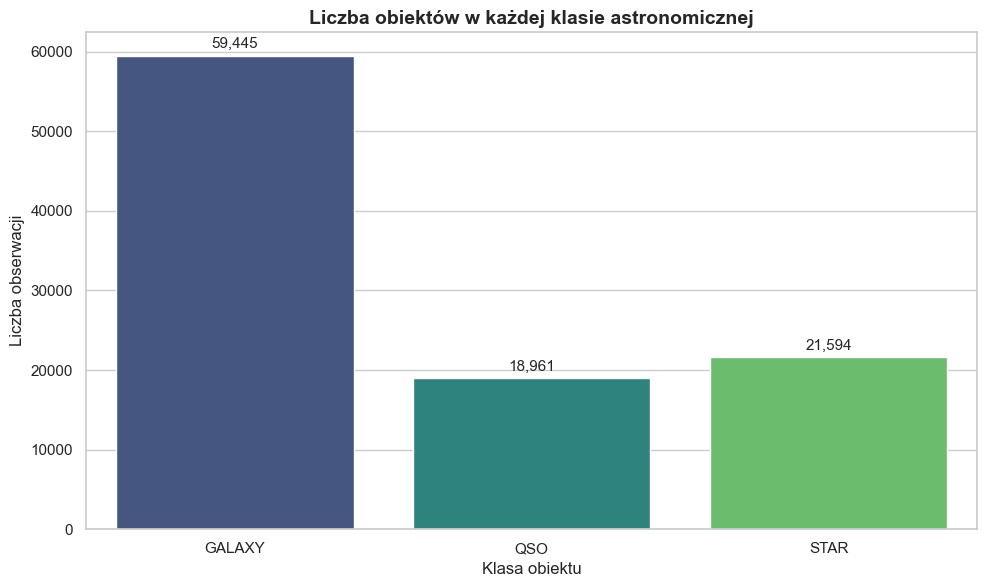

In [8]:
# --- Wykres słupkowy liczności klas ---
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index,
    palette="viridis",
    legend=False,
    ax=ax
)

ax.set_title("Liczba obiektów w każdej klasie astronomicznej", fontsize=14, fontweight="bold")
ax.set_xlabel("Klasa obiektu", fontsize=12)
ax.set_ylabel("Liczba obserwacji", fontsize=12)

for index, value in enumerate(class_counts.values):
    ax.text(index, value + max(class_counts.values) * 0.01, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

### Interpretacja — wykres słupkowy

Wizualizacja potwierdza rozkład liczności poszczególnych klas. Jeśli jedna klasa dominuje nad pozostałymi, model może mieć tendencję do przewidywania klasy większościowej — warto o tym pamiętać przy ocenie metryk (accuracy vs. F1-score).

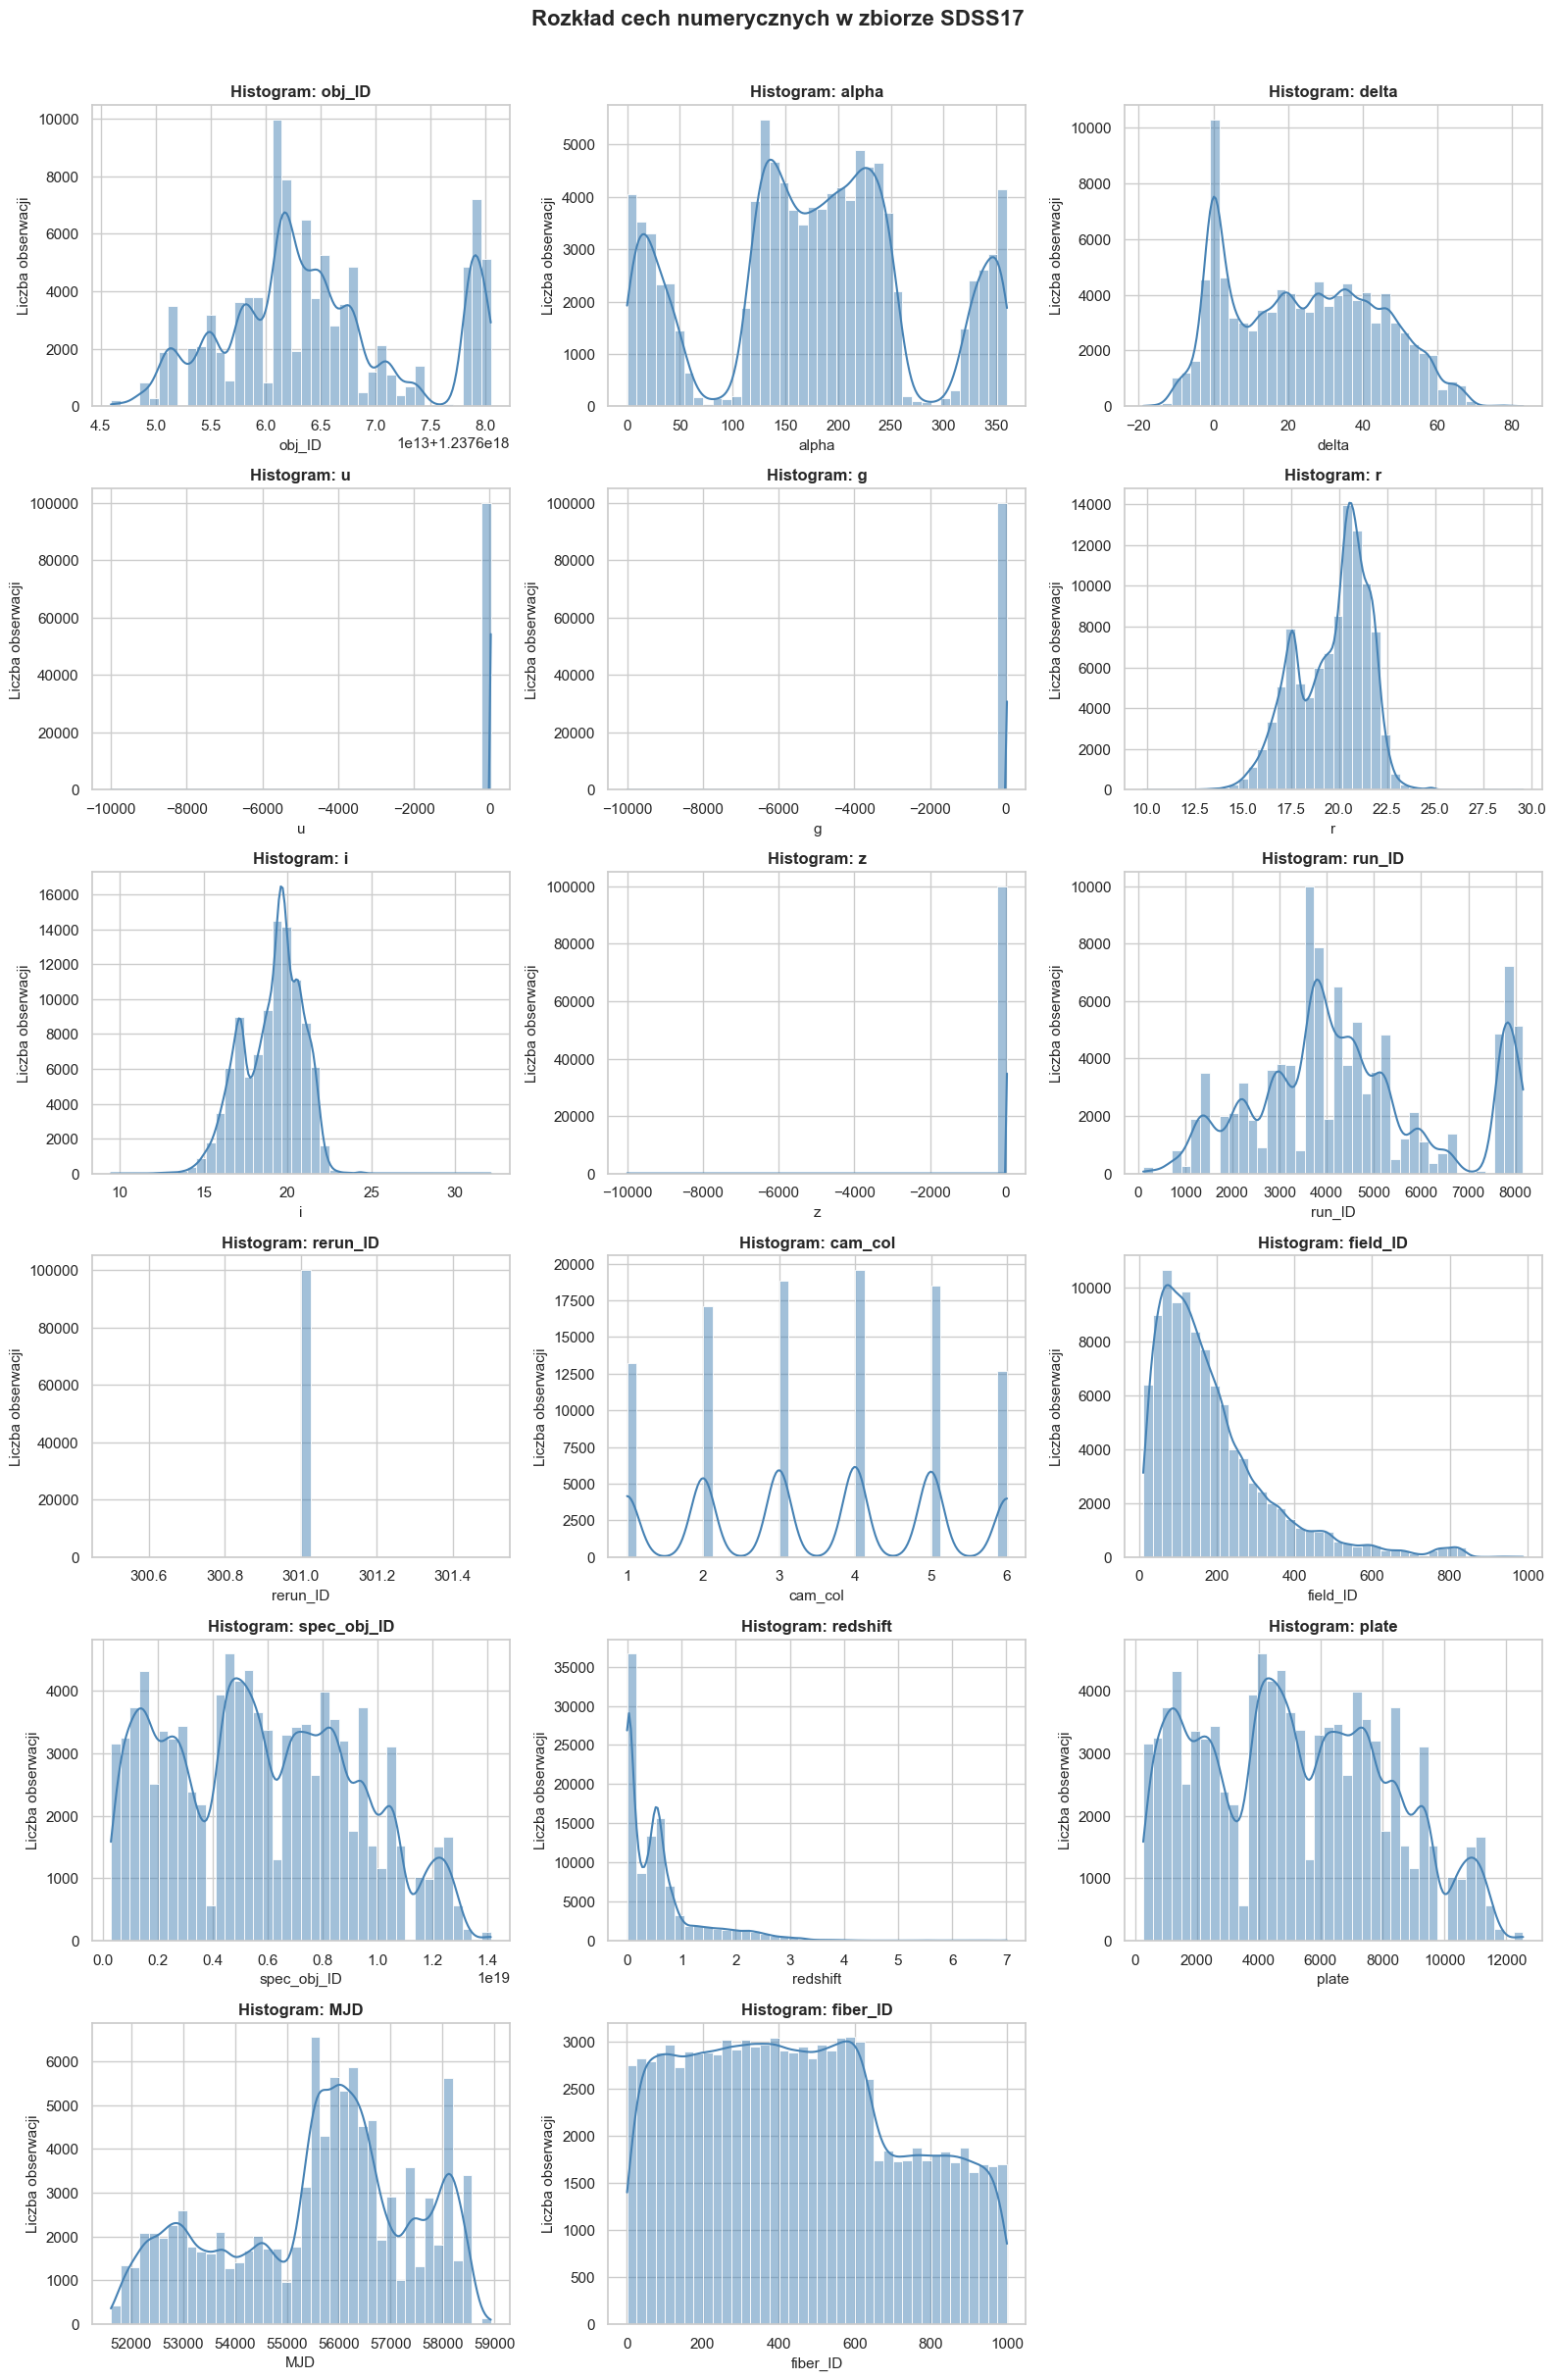

In [9]:
# --- Histogramy wszystkich cech numerycznych ---
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
n_features = len(numeric_columns)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    sns.histplot(df[column], bins=40, kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Histogram: {column}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(column, fontsize=11)
    axes[i].set_ylabel("Liczba obserwacji", fontsize=11)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Rozkład cech numerycznych w zbiorze SDSS17", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Interpretacja — histogramy

Histogramy pokazują kształt rozkładów poszczególnych cech. Magnitudy (`u`, `g`, `r`, `i`, `z`) mają typowy rozkład astronomiczny, natomiast kolumny identyfikacyjne (`obj_ID`, `spec_obj_ID`) przyjmują unikalne, rozproszone wartości — nie niosą informacji predykcyjnej o klasie obiektu.

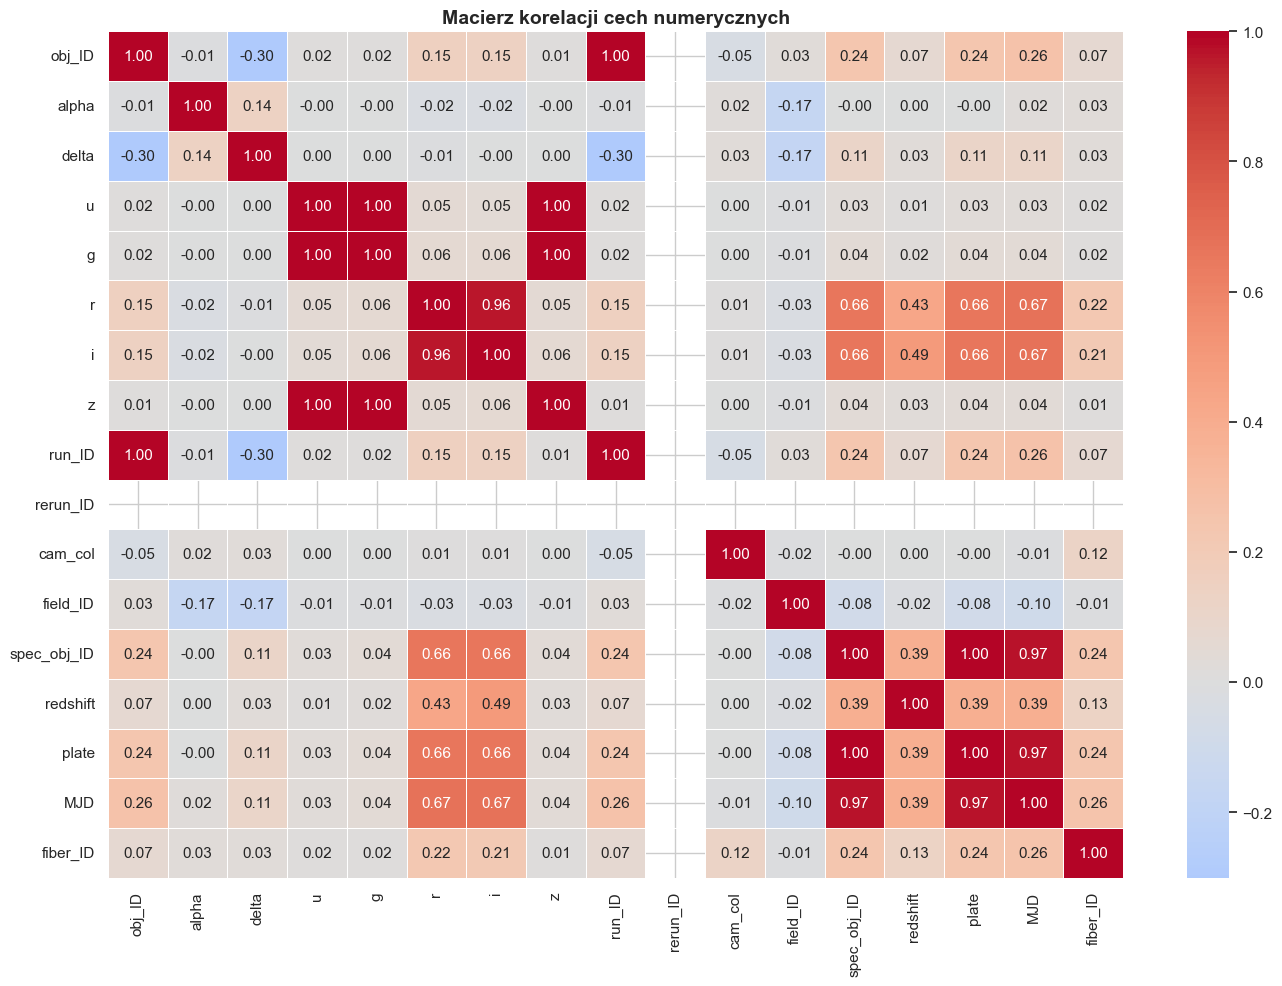

In [10]:
# --- Macierz korelacji (heatmap) ---
correlation_matrix = df[numeric_columns].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Macierz korelacji cech numerycznych", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Interpretacja — macierz korelacji

Pasma fotometryczne (`u`, `g`, `r`, `i`, `z`) wykazują **silną dodatnią korelację** — obiekty jaśniejsze w jednym paśmie zwykle są jaśniejsze w pozostałych. `redshift` koreluje z klasą kwazarów. Identyfikatory SDSS nie powinny być traktowane jako cechy predykcyjne.

In [11]:
# --- Analiza cech identyfikacyjnych ---
ID_COLUMNS = [
    "obj_ID",
    "spec_obj_ID",
    "run_ID",
    "rerun_ID",
    "cam_col",
    "field_ID",
    "plate",
    "MJD",
    "fiber_ID",
]

existing_id_columns = [col for col in ID_COLUMNS if col in df.columns]
feature_candidates = [col for col in df.columns if col not in existing_id_columns + [TARGET_COLUMN]]

print("--- Cechy identyfikacyjne / metadane obserwacji (do usunięcia przed modelowaniem) ---")
for col in existing_id_columns:
    print(f"  • {col}: unikalnych wartości = {df[col].nunique():,}")

print("\n--- Potencjalne cechy predykcyjne ---")
print(feature_candidates)

print("\n--- Komentarz ---")
print(
    "Kolumny obj_ID i spec_obj_ID to unikalne identyfikatory obiektów w bazie SDSS. "
    "Pozostałe kolumny metadanych (run_ID, plate, MJD itd.) opisują warunki obserwacji, "
    "a nie fizyczne właściwości obiektu. Do klasyfikacji astronomicznej wykorzystamy "
    "współrzędne, pasma fotometryczne oraz redshift."
)

--- Cechy identyfikacyjne / metadane obserwacji (do usunięcia przed modelowaniem) ---
  • obj_ID: unikalnych wartości = 78,053
  • spec_obj_ID: unikalnych wartości = 100,000
  • run_ID: unikalnych wartości = 430
  • rerun_ID: unikalnych wartości = 1
  • cam_col: unikalnych wartości = 6
  • field_ID: unikalnych wartości = 856
  • plate: unikalnych wartości = 6,284
  • MJD: unikalnych wartości = 2,180
  • fiber_ID: unikalnych wartości = 1,000

--- Potencjalne cechy predykcyjne ---
['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

--- Komentarz ---
Kolumny obj_ID i spec_obj_ID to unikalne identyfikatory obiektów w bazie SDSS. Pozostałe kolumny metadanych (run_ID, plate, MJD itd.) opisują warunki obserwacji, a nie fizyczne właściwości obiektu. Do klasyfikacji astronomicznej wykorzystamy współrzędne, pasma fotometryczne oraz redshift.


### Podsumowanie sekcji 3

EDA wykazała, że:
- zbiór zawiera **3 klasy** astronomiczne (`GALAXY`, `QSO`, `STAR`);
- cechy fotometryczne są silnie skorelowane;
- kolumny identyfikacyjne nie powinny trafić do modelu;
- cechy numeryczne mają różne skale — standaryzacja będzie konieczna w sekcji 4.

# Sekcja 4 – Przygotowanie danych

Przygotowujemy dane do trenowania sieci neuronowej: usuwamy kolumny identyfikacyjne, kodujemy etykiety, standaryzujemy cechy i dzielimy zbiór na podzbiory treningowy, walidacyjny i testowy.

In [12]:
# --- 1. Usunięcie kolumn identyfikacyjnych ---
df_model = df.drop(columns=existing_id_columns).copy()

print(f"Kolumny po usunięciu identyfikatorów: {df_model.columns.tolist()}")
print(f"Nowy rozmiar: {df_model.shape}")

Kolumny po usunięciu identyfikatorów: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'class', 'redshift']
Nowy rozmiar: (100000, 9)


In [13]:
# --- 2. Kodowanie zmiennej docelowej ---
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_model[TARGET_COLUMN])

class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("--- Mapowanie klas na etykiety numeryczne ---")
for class_name, encoded_value in class_mapping.items():
    print(f"  {class_name} -> {encoded_value}")

# --- 3. Podział na macierz cech X i wektor etykiet y ---
X = df_model.drop(columns=[TARGET_COLUMN])

print(f"\nKształt X: {X.shape}")
print(f"Kształt y: {y.shape}")
print(f"\nCechy wejściowe: {X.columns.tolist()}")

--- Mapowanie klas na etykiety numeryczne ---
  GALAXY -> 0
  QSO -> 1
  STAR -> 2

Kształt X: (100000, 8)
Kształt y: (100000,)

Cechy wejściowe: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']


In [14]:
# --- 4. Standaryzacja cech ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("--- Statystyki po standaryzacji (powinny mieć ~0 średnią i ~1 odchylenie) ---")
display(X_scaled.describe().loc[["mean", "std"]].round(4))

--- Statystyki po standaryzacji (powinny mieć ~0 średnią i ~1 odchylenie) ---


,alpha,delta,u,g,r,i,z,redshift
mean,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [15]:
# --- 5. Podział na train / validation / test (70% / 15% / 15%) ---
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("--- Rozmiary zbiorów ---")
print(f"Train:      {X_train.shape[0]:,} próbek ({X_train.shape[0] / len(y) * 100:.1f}%)")
print(f"Validation: {X_val.shape[0]:,} próbek ({X_val.shape[0] / len(y) * 100:.1f}%)")
print(f"Test:       {X_test.shape[0]:,} próbek ({X_test.shape[0] / len(y) * 100:.1f}%)")
print(f"\nLiczba cech: {X_train.shape[1]}")

--- Rozmiary zbiorów ---
Train:      70,000 próbek (70.0%)
Validation: 15,000 próbek (15.0%)
Test:       15,000 próbek (15.0%)

Liczba cech: 8


In [16]:
# --- 6. Rozkład klas po podziale (stratyfikacja) ---
def show_class_distribution(labels, set_name):
    """Wyświetla liczność i udział procentowy klas w danym podzbiorze."""
    counts = pd.Series(labels).value_counts().sort_index()
    percents = (counts / len(labels) * 100).round(2)
    decoded_labels = label_encoder.inverse_transform(counts.index)

    summary = pd.DataFrame({
        "klasa": decoded_labels,
        "liczność": counts.values,
        "udział_%": percents.values
    })

    print(f"\n--- Rozkład klas: {set_name} ---")
    display(summary)


show_class_distribution(y_train, "TRAIN")
show_class_distribution(y_val, "VALIDATION")
show_class_distribution(y_test, "TEST")


--- Rozkład klas: TRAIN ---


,klasa,liczność,udział_%
0,GALAXY,41611,59.44
1,QSO,13273,18.96
2,STAR,15116,21.59



--- Rozkład klas: VALIDATION ---


,klasa,liczność,udział_%
0,GALAXY,8917,59.45
1,QSO,2844,18.96
2,STAR,3239,21.59



--- Rozkład klas: TEST ---


,klasa,liczność,udział_%
0,GALAXY,8917,59.45
1,QSO,2844,18.96
2,STAR,3239,21.59


In [17]:
# --- 7. Zapis scalera i enkodera etykiet ---
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

scaler_path = ARTIFACTS_DIR / "standard_scaler.joblib"
encoder_path = ARTIFACTS_DIR / "label_encoder.joblib"

joblib.dump(scaler, scaler_path)
joblib.dump(label_encoder, encoder_path)

print(f"Scaler zapisany do:   {scaler_path.resolve()}")
print(f"Encoder zapisany do:  {encoder_path.resolve()}")
print("\nDane są gotowe do dalszego trenowania sieci neuronowej w kolejnych sekcjach projektu.")

Scaler zapisany do:   C:\University\Sem6\SSNiAUG\Task2\artifacts\standard_scaler.joblib
Encoder zapisany do:  C:\University\Sem6\SSNiAUG\Task2\artifacts\label_encoder.joblib

Dane są gotowe do dalszego trenowania sieci neuronowej w kolejnych sekcjach projektu.


### Podsumowanie sekcji 4

W tej sekcji wykonano pełne przygotowanie danych:

1. Usunięto **9 kolumn identyfikacyjnych** i metadanych obserwacji.
2. Zmienna docelowa `class` została zakodowana przez **LabelEncoder**.
3. Utworzono macierz cech **X** (8 cech: współrzędne, pasma fotometryczne, redshift) i wektor **y**.
4. Zastosowano **StandardScaler** do normalizacji cech.
5. Podzielono dane stratyfikowanie w proporcji **70% / 15% / 15%** (train / val / test).
6. Zweryfikowano zachowanie rozkładu klas w każdym podzbiorze.
7. Zapisano **scaler** i **label encoder** w folderze `artifacts/`.

---

**Koniec notebooka.** Kolejne sekcje projektu mogą rozpocząć budowę i trenowanie architektury sieci neuronowej na przygotowanych zbiorach `X_train`, `X_val`, `X_test`.